In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
# Path to the dataset
data_path = r'../1_data/raw/metadata.csv'

print(df.shape)      # rows, columns
print(df.columns)    # column names
df.head()            # first few rows
df.info()            # data types + missing values

(1056660, 6)
Index(['cord_uid', 'title', 'abstract', 'publish_time', 'journal',
       'word_count'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1056660 entries, 0 to 1056659
Data columns (total 6 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   cord_uid      1056660 non-null  object        
 1   title         1056157 non-null  object        
 2   abstract      1056660 non-null  object        
 3   publish_time  518871 non-null   datetime64[ns]
 4   journal       969338 non-null   object        
 5   word_count    1056660 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 48.4+ MB


In [13]:
# Load the metadata (loading only necessary columns to save RAM)
cols_to_use = ['cord_uid', 'title', 'publish_time', 'abstract', 'journal']
df = pd.read_csv(data_path, usecols=cols_to_use, low_memory=False)

In [6]:
# 1. Total Papers
total_papers = len(df)
print(f"Total Papers in CORD-19: {total_papers:,}")

Total Papers in CORD-19: 1,056,660


In [7]:
# 2. Date Range
# Convert publish_time to datetime (handling errors for non-standard formats)
df['publish_time'] = pd.to_datetime(df['publish_time'], errors='coerce')
date_min = df['publish_time'].min()
date_max = df['publish_time'].max()
print(f"Date Range: {date_min.date()} to {date_max.date()}")

Date Range: 1856-04-01 to 2024-04-20


In [9]:
# 3. Word Count Distribution (Abstracts)
# Fill NaN abstracts with empty strings
df['abstract'] = df['abstract'].fillna('')
df['word_count'] = df['abstract'].apply(lambda x: len(x.split()))
print("\nWord Count Statistics (Abstracts):")
print(df['word_count'].describe())


Word Count Statistics (Abstracts):
count    1.056660e+06
mean     1.646091e+02
std      1.242203e+02
min      0.000000e+00
25%      5.500000e+01
50%      1.790000e+02
75%      2.470000e+02
max      1.800000e+04
Name: word_count, dtype: float64


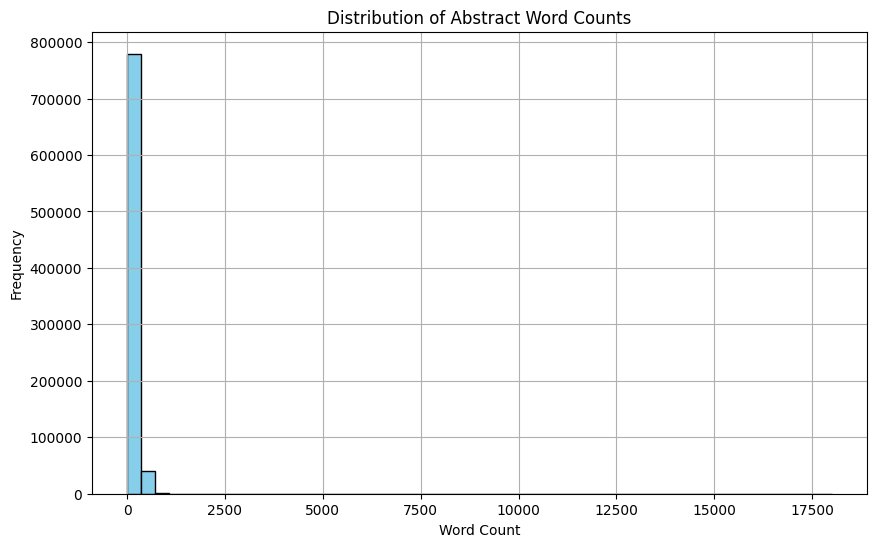

In [10]:
# Optional: Plotting the distribution
plt.figure(figsize=(10, 6))
df[df['word_count'] > 0]['word_count'].hist(bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Abstract Word Counts')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()